In [2]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
spe_data = pd.read_excel("data/species_866.xlsx", index_col=0)
food_data_spear = pd.read_excel('data/FFQA862.xlsx', index_col=0)
participants_data = pd.read_excel('data/ethnicity_866.xlsx', index_col=0)

,FREG5_Ethnic_Group,FREG7_Gender,FREG8_Age
FREG1_Barcode,,,
10004,C,F,66.1
10005,C,M,68.6
10006,I,M,48.1
10012,I,M,45.2
10026,C,M,61.5
...,...,...,...
PSA-2971-1,M,M,45.6
PSA-3006-5,C,F,42.1
PSA-3012-3,M,M,59.8


In [37]:
common_indices = spe_data.index.intersection(food_data_spear.index)
spe_data = spe_data.loc[common_indices]
food_data_spear = food_data_spear.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [40]:
participants_data

,FREG5_Ethnic_Group,FREG7_Gender,FREG8_Age
10004,C,F,66.1
10005,C,M,68.6
10006,I,M,48.1
10012,I,M,45.2
10026,C,M,61.5
...,...,...,...
PSA-2971-1,M,M,45.6
PSA-3006-5,C,F,42.1
PSA-3012-3,M,M,59.8
PSA-3030-5,M,F,36.3


In [41]:
# Convert data to numeric and handle non-numeric entries
spe_data = spe_data.apply(pd.to_numeric, errors='coerce')
food_data_spear = food_data_spear.apply(pd.to_numeric, errors='coerce')
#participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')


In [42]:
participants_data

,FREG5_Ethnic_Group,FREG7_Gender,FREG8_Age
10004,C,F,66.1
10005,C,M,68.6
10006,I,M,48.1
10012,I,M,45.2
10026,C,M,61.5
...,...,...,...
PSA-2971-1,M,M,45.6
PSA-3006-5,C,F,42.1
PSA-3012-3,M,M,59.8
PSA-3030-5,M,F,36.3


In [43]:

def adjust_for_covariates(data, covariates, categorical_vars=[]):
    # Generate dummy variables for categorical variables
    if categorical_vars:
        covariates = pd.get_dummies(covariates, columns=categorical_vars, drop_first=True)
    
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid

    return adjusted_data

# Adjust microbiome and diet data
# Ensure that 'FREG5_Ethnic_Group' is included as a categorical variable
adjusted_spe_data = adjust_for_covariates(spe_data, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])
adjusted_food_spear = adjust_for_covariates(food_data_spear, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])



In [44]:
correlations_spe = pd.DataFrame(index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)
p_values_spe = pd.DataFrame(index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_spe = correlations_spe.astype(float)  # Convert to float
p_values_spe = p_values_spe.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_spe.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value

In [45]:
for microbe in adjusted_spe_data.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_spe_data[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_spe_data[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_spe.loc[microbe, nutrient] = corr
            p_values_spe.loc[microbe, nutrient] = pval
        else:
            correlations_spe.loc[microbe, nutrient] = np.nan
            p_values_spe.loc[microbe, nutrient] = np.nan

/Users/qd/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/stats.py:4264: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


In [74]:
p_flat = p_values_spe.values.flatten()
reject, corrected_pvals_spe, _, _ = multipletests(p_flat, alpha=0.05, method='fdr_bh')
significant_matrix_spe = pd.DataFrame(reject.reshape(p_values_spe.shape), index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_spe.sum(axis=1)

# Filter species with at least 10 significant correlations
significant_species = true_counts >= 14
filtered_species_spe = correlations_spe.loc[significant_species.index[significant_species]]


In [75]:
filtered_species_spe

,Fish,Crustacean,Mollusk,Poultry,Red_meat,Processed_meat,Dairy,Cruciferous_veg,Legumes,Mushrooms,Fruits,Papaya,Orange,Wholegrain,Chapati,Idli_Thosai,Noodle_dishes,Deep_fried,Coffee,Tea
Rhizobium sp. Pop5,-0.053528,0.087158,0.244348,0.167070,0.011178,0.211741,-0.118476,0.030925,-0.096527,0.090975,-0.110817,-0.265614,-0.152113,-0.134896,0.410342,-0.349508,0.071232,0.097289,-0.072883,-0.029892
Methylobacterium mesophilicum,0.032511,0.125237,0.277493,0.118795,0.022421,0.197842,-0.085957,0.059978,-0.105007,0.067388,-0.108894,-0.218404,-0.157222,-0.115565,0.288027,-0.246906,0.089433,0.102950,-0.004092,0.019077
Bartonella bacilliformis,0.019701,-0.101134,-0.216514,-0.146655,0.004496,-0.222455,0.094821,-0.047255,0.136256,-0.088216,0.073648,0.163455,0.096871,0.081334,-0.418119,0.461139,-0.071344,-0.141059,0.039329,0.088771
Bartonella bovis,0.018119,-0.117822,-0.262597,-0.112410,-0.007344,-0.181754,0.127420,-0.040417,0.188050,-0.061345,0.088986,0.236316,0.119276,0.085126,-0.089571,0.243095,-0.115723,-0.085114,-0.014728,0.006305
Bartonella australis,-0.060165,0.111621,0.261003,0.145514,-0.003120,0.131230,-0.124809,0.071367,-0.110286,0.090283,-0.108979,-0.297372,-0.136395,-0.119337,0.275819,-0.346040,0.102785,0.068894,-0.009132,0.002998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Gamaleyavirus IME11,0.002505,-0.108565,-0.239216,-0.152863,0.001952,-0.242306,0.094209,-0.041250,0.144521,-0.075183,0.084661,0.186383,0.116521,0.093185,-0.375289,0.398228,-0.081724,-0.141499,0.032854,0.065506
Aguilavirus mEp213,-0.051647,0.106595,0.199146,0.167910,0.005904,0.108824,-0.123032,0.081477,-0.035936,0.146810,-0.089334,-0.241990,-0.100270,-0.116539,0.511189,-0.500455,0.057402,0.081543,-0.072528,-0.053555
Cequinquevirus Ld25A,-0.054170,0.111641,0.239854,0.165032,0.013017,0.117436,-0.131583,0.071728,-0.107117,0.115114,-0.111259,-0.287829,-0.108670,-0.103059,0.278957,-0.389899,0.100106,0.071669,-0.021101,-0.008224
Alegriavirus av2B8,-0.050973,0.106635,0.186934,0.175719,0.007537,0.105713,-0.122356,0.088011,-0.040717,0.158296,-0.082111,-0.238901,-0.095315,-0.111251,0.511060,-0.501603,0.054561,0.090857,-0.066285,-0.049046


<Figure size 1440x1440 with 0 Axes>

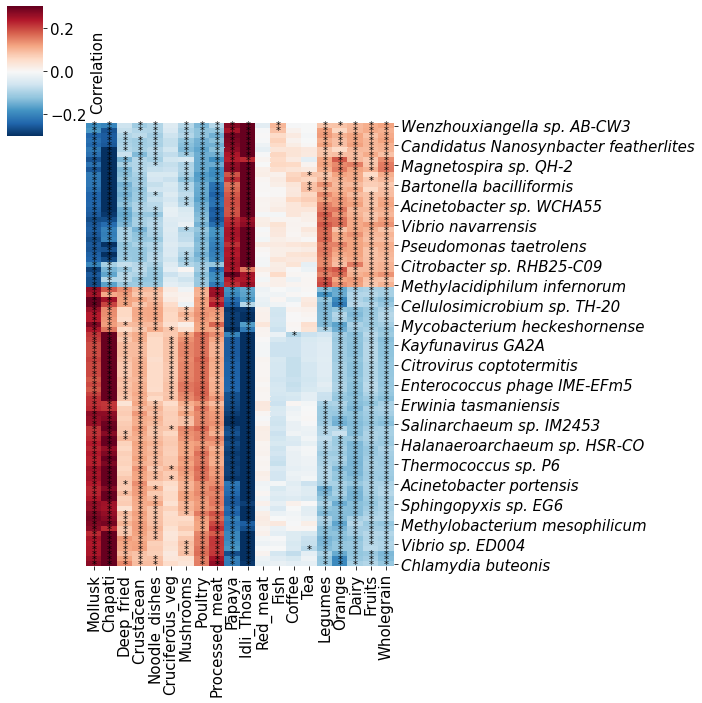

In [76]:
filtered_significance_matrix_spe = significant_matrix_spe.loc[filtered_species_spe.index, filtered_species_spe.columns]
clipped_correlations_spe = np.clip(filtered_species_spe, -0.3, 0.3)


plt.figure(figsize=(20, 20))
ax = sns.clustermap(clipped_correlations_spe, cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.3, vmax=0.3, row_cluster=True, col_cluster=True)

ax.ax_row_dendrogram.set_visible(False)
ax.ax_col_dendrogram.set_visible(False)

row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

for (i, j), significant in np.ndenumerate(filtered_significance_matrix_spe):
    if significant:
        # Find the new position in the clustered heatmap
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]

# Set the y-axis labels to italicized text
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic'})
plt.rc('font', size=15)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=15)

plt.show()

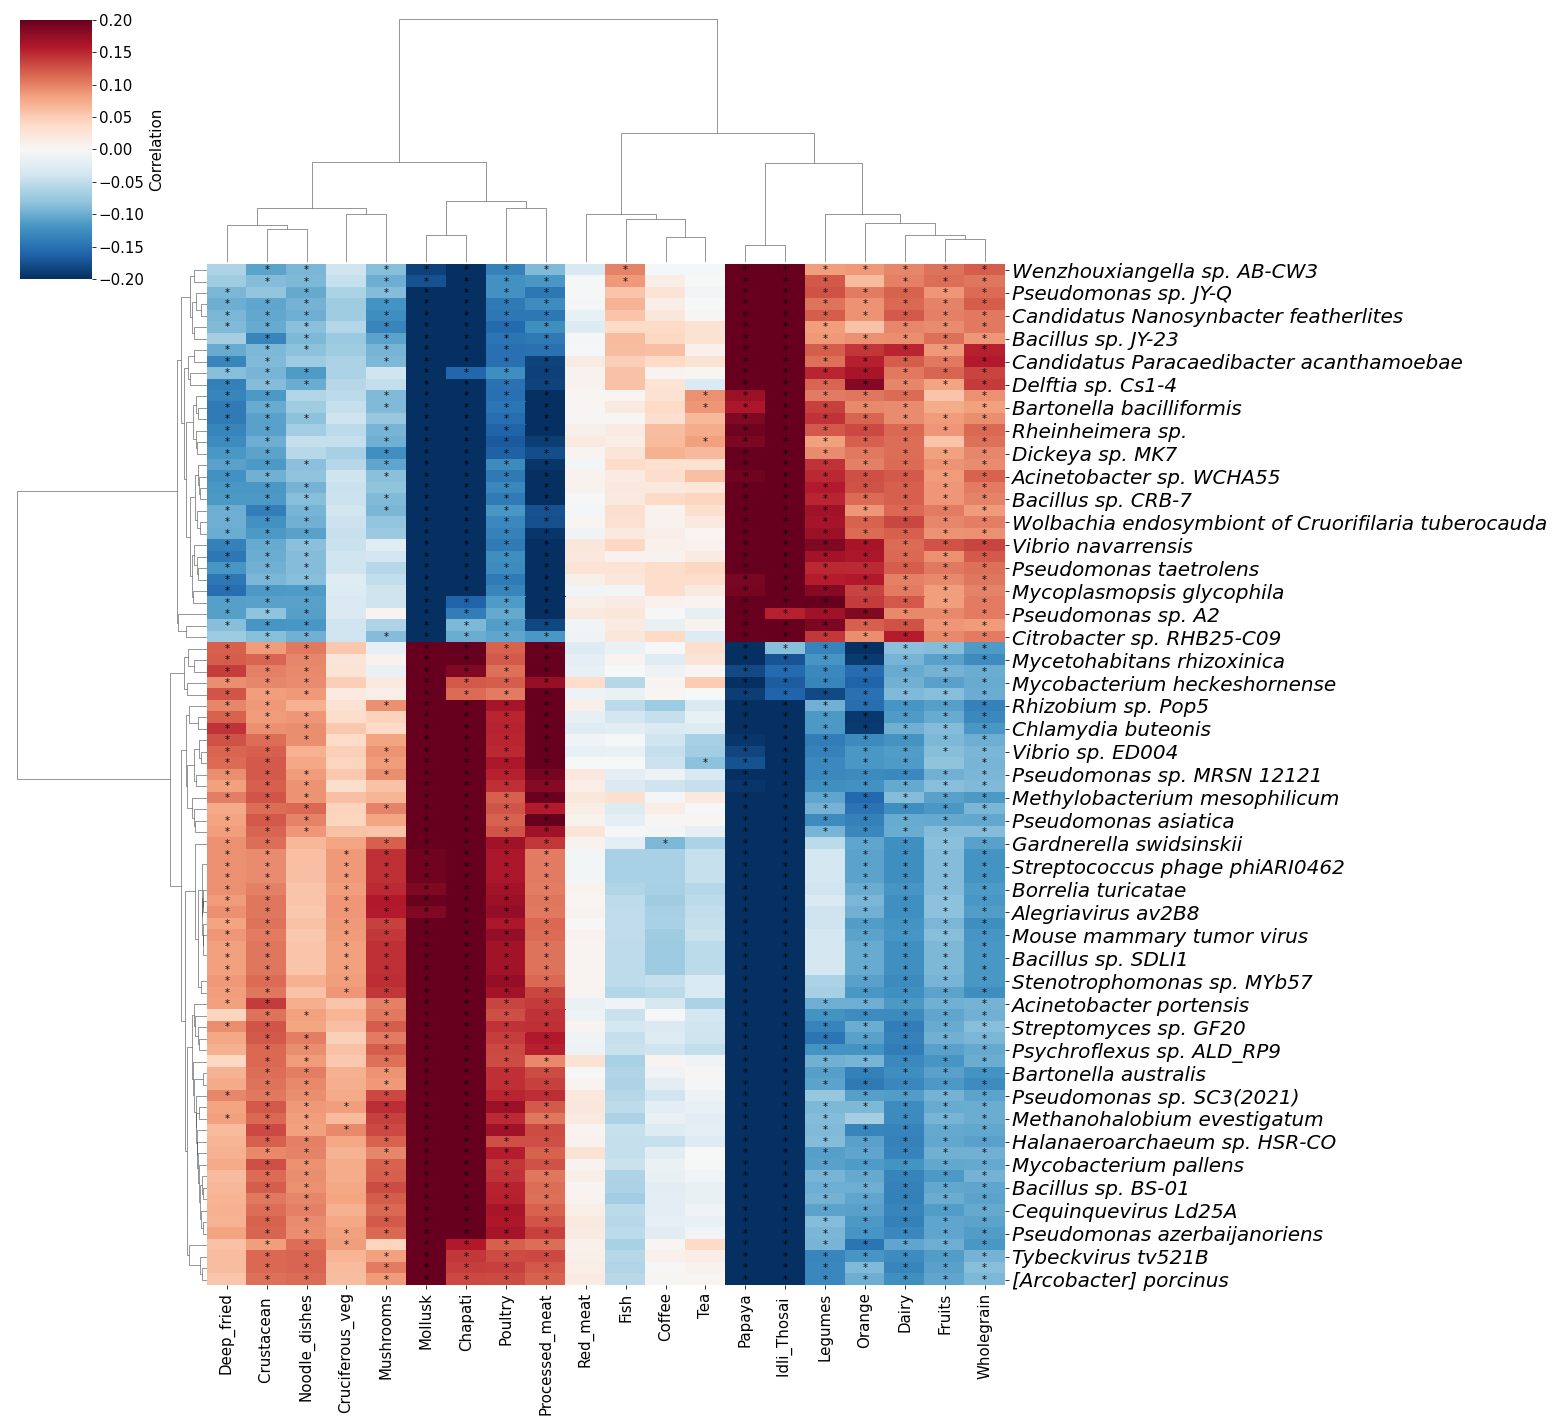

In [78]:
# Assuming filtered_species_scfa, significant_matrix_scfa are defined as per your context
# Clipping values
clipped_correlations_spe = np.clip(filtered_species_spe, -0.2, 0.2)

# Setup figure settings beforehand
plt.rc('font', size=15)  # Adjusting global font size
plt.rc('axes', labelsize=15, titlesize=15)  # Adjusting label and title sizes

# Create clustermap
ax = sns.clustermap(
    clipped_correlations_spe,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={'label': 'Correlation'},
    vmin=-0.2,
    vmax=0.2,
    row_cluster=True,
    col_cluster=True,
    figsize=(20, 20)  # Adjust size directly here if needed
)

# Making dendrograms visible to check the layout
ax.ax_row_dendrogram.set_visible(True)
ax.ax_col_dendrogram.set_visible(True)

# Get the order of rows and columns after clustering
row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

# Highlight significant cells
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_spe):
    if significant:
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

# Adjust y-tick labels
y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic', 'fontsize': 20})
#plt.savefig('figure/food_all_spe_heatmap.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
## nutrient

In [79]:
food_row_order = ax.dendrogram_row.reordered_ind

In [80]:
food_row_order

[28,
 54,
 21,
 8,
 67,
 36,
 48,
 6,
 12,
 5,
 38,
 30,
 2,
 84,
 27,
 16,
 17,
 55,
 34,
 40,
 49,
 9,
 10,
 65,
 33,
 14,
 23,
 52,
 53,
 62,
 19,
 3,
 15,
 42,
 37,
 61,
 44,
 74,
 0,
 29,
 63,
 56,
 32,
 60,
 18,
 51,
 1,
 7,
 24,
 71,
 46,
 83,
 80,
 81,
 64,
 79,
 87,
 39,
 77,
 88,
 47,
 85,
 26,
 78,
 35,
 68,
 45,
 41,
 59,
 13,
 4,
 73,
 20,
 31,
 75,
 58,
 70,
 69,
 43,
 72,
 50,
 76,
 86,
 22,
 25,
 66,
 82,
 11,
 57]

In [81]:
spe_data = pd.read_excel("data/species_866.xlsx", index_col=0)
food_data_spear = pd.read_excel('data/FFQB800.xlsx', index_col=0)
participants_data = pd.read_excel('data/ethnicity_866.xlsx', index_col=0)

In [82]:
common_indices = spe_data.index.intersection(food_data_spear.index)
spe_data = spe_data.loc[common_indices]
food_data_spear = food_data_spear.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [84]:
spe_data

,Starkeya novella,Starkeya sp. ORNL1,Xanthobacter autotrophicus,Xanthobacter dioxanivorans,Xanthobacter sp. YC-JY1,Pseudolabrys taiwanensis,Pseudolabrys sp. FHR47,Ancylobacter pratisalsi,Ancylobacter polymorphus,Ancylobacter sp. TS-1,...,Acetobacter sp. KACC 21233,Sneathiella sp. PHK-P5,Arthrobacter sp. QL17,Faecalibacterium sp. I2392,Candidatus Cyclonatronum proteinivorum,Arthrobacter sp. zg-Y809,Thermomonas sp. IMCC34681,[Clostridium] spiroforme,Allobaculum mucolyticum,Methanocaldococcus sp. SG7
10004,126,0,0,0,0,0,0,0,0,0,...,0,0,0,526,0,0,0,53,0,0
10005,321,0,0,0,0,0,0,0,0,0,...,0,0,0,4077,74,0,0,159,129,0
10006,84,0,0,0,0,0,0,0,0,0,...,0,0,0,7056,33,69,0,2697,174,0
10012,397,0,0,0,0,19,0,0,0,0,...,0,0,0,35313,0,0,0,79,52,0
10026,340,0,0,0,0,0,0,0,0,0,...,0,0,0,13107,50,0,0,101,187,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PSA-2971-1,772,0,0,35,0,0,0,0,0,0,...,0,0,0,11081,0,0,0,188,158,0
PSA-3006-5,399,63,0,0,0,0,0,0,0,0,...,0,0,0,24620,0,0,0,41,91,0
PSA-3012-3,611,0,0,31,0,0,0,39,0,0,...,0,0,0,1497,0,0,0,115,105,0
PSA-3030-5,157,0,0,0,0,0,0,0,0,0,...,0,0,0,22577,0,0,0,1885,0,0


In [85]:
# Convert data to numeric and handle non-numeric entries
spe_data = spe_data.apply(pd.to_numeric, errors='coerce')
food_data_spear = food_data_spear.apply(pd.to_numeric, errors='coerce')
#participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')

In [86]:
def adjust_for_covariates(data, covariates, categorical_vars=[]):
    # Generate dummy variables for categorical variables
    if categorical_vars:
        covariates = pd.get_dummies(covariates, columns=categorical_vars, drop_first=True)
    
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid

    return adjusted_data

# Adjust microbiome and diet data
# Ensure that 'FREG5_Ethnic_Group' is included as a categorical variable
adjusted_spe_data = adjust_for_covariates(spe_data, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])
adjusted_food_spear = adjust_for_covariates(food_data_spear, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])




In [87]:
correlations_spe = pd.DataFrame(index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)
p_values_spe = pd.DataFrame(index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_spe = correlations_spe.astype(float)  # Convert to float
p_values_spe = p_values_spe.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_spe.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value

In [88]:
for microbe in adjusted_spe_data.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_spe_data[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_spe_data[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_spe.loc[microbe, nutrient] = corr
            p_values_spe.loc[microbe, nutrient] = pval
        else:
            correlations_spe.loc[microbe, nutrient] = np.nan
            p_values_spe.loc[microbe, nutrient] = np.nan

/Users/qd/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/stats.py:4264: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


In [89]:
#p_flat = p_values_spe.values.flatten()
#reject, corrected_pvals_spe, _, _ = multipletests(p_flat, alpha=0.2, method='fdr_bh')
#significant_matrix_spe = pd.DataFrame(reject.reshape(p_values_spe.shape), index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
#true_counts = significant_matrix_spe.sum(axis=1)

# Filter species with at least 10 significant correlations
#significant_species = true_counts >= 0
#filtered_species_spe = correlations_spe.loc[significant_species.index[significant_species]]
#significant_species

#filtered_species_spe = filtered_species_spe.iloc[food_row_order, :]
#filtered_species_spe

,Energy,Protein,Total_fat,Saturated_fatty_acid,MUFA,PUFA,CHO,starch,sugar,fibre,VitaminA,VitaminC,Calcium,Iron,Bcarotene,Thiamin,Riboflavin,Potassium,Zinc
Wenzhouxiangella sp. AB-CW3,0.021289,0.025188,0.022313,0.013497,0.017535,0.036871,0.014792,-0.005378,0.076861,0.055213,0.044471,0.066658,0.089718,0.063361,0.080255,0.070804,0.064662,0.060333,0.032209
Mariniplasma anaerobium,0.006938,0.017773,0.018917,0.004829,0.011161,0.046466,-0.010834,-0.028624,0.062903,0.035349,0.038153,0.055502,0.078987,0.035607,0.068890,0.054883,0.048526,0.052350,0.025462
Pseudomonas sp. JY-Q,-0.000470,0.009054,-0.000278,-0.011108,-0.003921,0.018655,-0.007220,-0.020287,0.041071,0.007236,0.008852,0.012944,0.053751,0.011015,0.041381,0.034370,0.026325,0.032150,0.004489
Altererythrobacter sp. BO-6,0.012216,0.023216,0.012583,-0.000839,0.010274,0.031814,0.006905,-0.003533,0.054752,0.023073,0.023282,0.041134,0.080277,0.033211,0.051351,0.050067,0.045787,0.044228,0.025276
Candidatus Nanosynbacter featherlites,0.006282,0.013721,0.002816,-0.005544,-0.000303,0.018125,0.006542,-0.005270,0.046626,0.013004,0.016684,0.021015,0.063479,0.017206,0.047855,0.035506,0.028113,0.034471,0.015194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pseudomonas azerbaijanoriens,-0.012133,-0.015327,-0.012938,-0.001083,-0.011759,-0.028841,-0.009234,0.010110,-0.062556,-0.027197,-0.023916,-0.024706,-0.077456,-0.025896,-0.043238,-0.048987,-0.042973,-0.047137,-0.015919
Thermotoga neapolitana,-0.016083,-0.016736,-0.011606,-0.000843,-0.008751,-0.025250,-0.018818,-0.000604,-0.067933,-0.027518,-0.004948,-0.010307,-0.060225,-0.022367,-0.038432,-0.046724,-0.035580,-0.043910,-0.012255
Tybeckvirus tv521B,-0.013088,-0.015912,-0.013791,-0.001816,-0.012645,-0.028564,-0.010013,0.009176,-0.063595,-0.027260,-0.017389,-0.027830,-0.070975,-0.022639,-0.056409,-0.049932,-0.038485,-0.049165,-0.014234
Rickettsia monacensis,-0.009232,-0.013269,-0.010901,0.000878,-0.010404,-0.026782,-0.006932,0.010859,-0.061462,-0.025504,-0.021129,-0.028527,-0.073619,-0.024345,-0.057531,-0.046068,-0.037810,-0.049706,-0.010278


In [101]:
p_flat = p_values_spe.values.flatten()
reject, corrected_pvals_spe, _, _ = multipletests(p_flat, alpha=0.3, method='fdr_bh')
significant_matrix_spe = pd.DataFrame(reject.reshape(p_values_spe.shape), index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_spe.sum(axis=1)

# Filter species with at least 10 significant correlations
significant_species = true_counts >= 1
filtered_species_spe = correlations_spe.loc[significant_species.index[significant_species]]
filtered_species_spe

,Energy,Protein,Total_fat,Saturated_fatty_acid,MUFA,PUFA,CHO,starch,sugar,fibre,VitaminA,VitaminC,Calcium,Iron,Bcarotene,Thiamin,Riboflavin,Potassium,Zinc


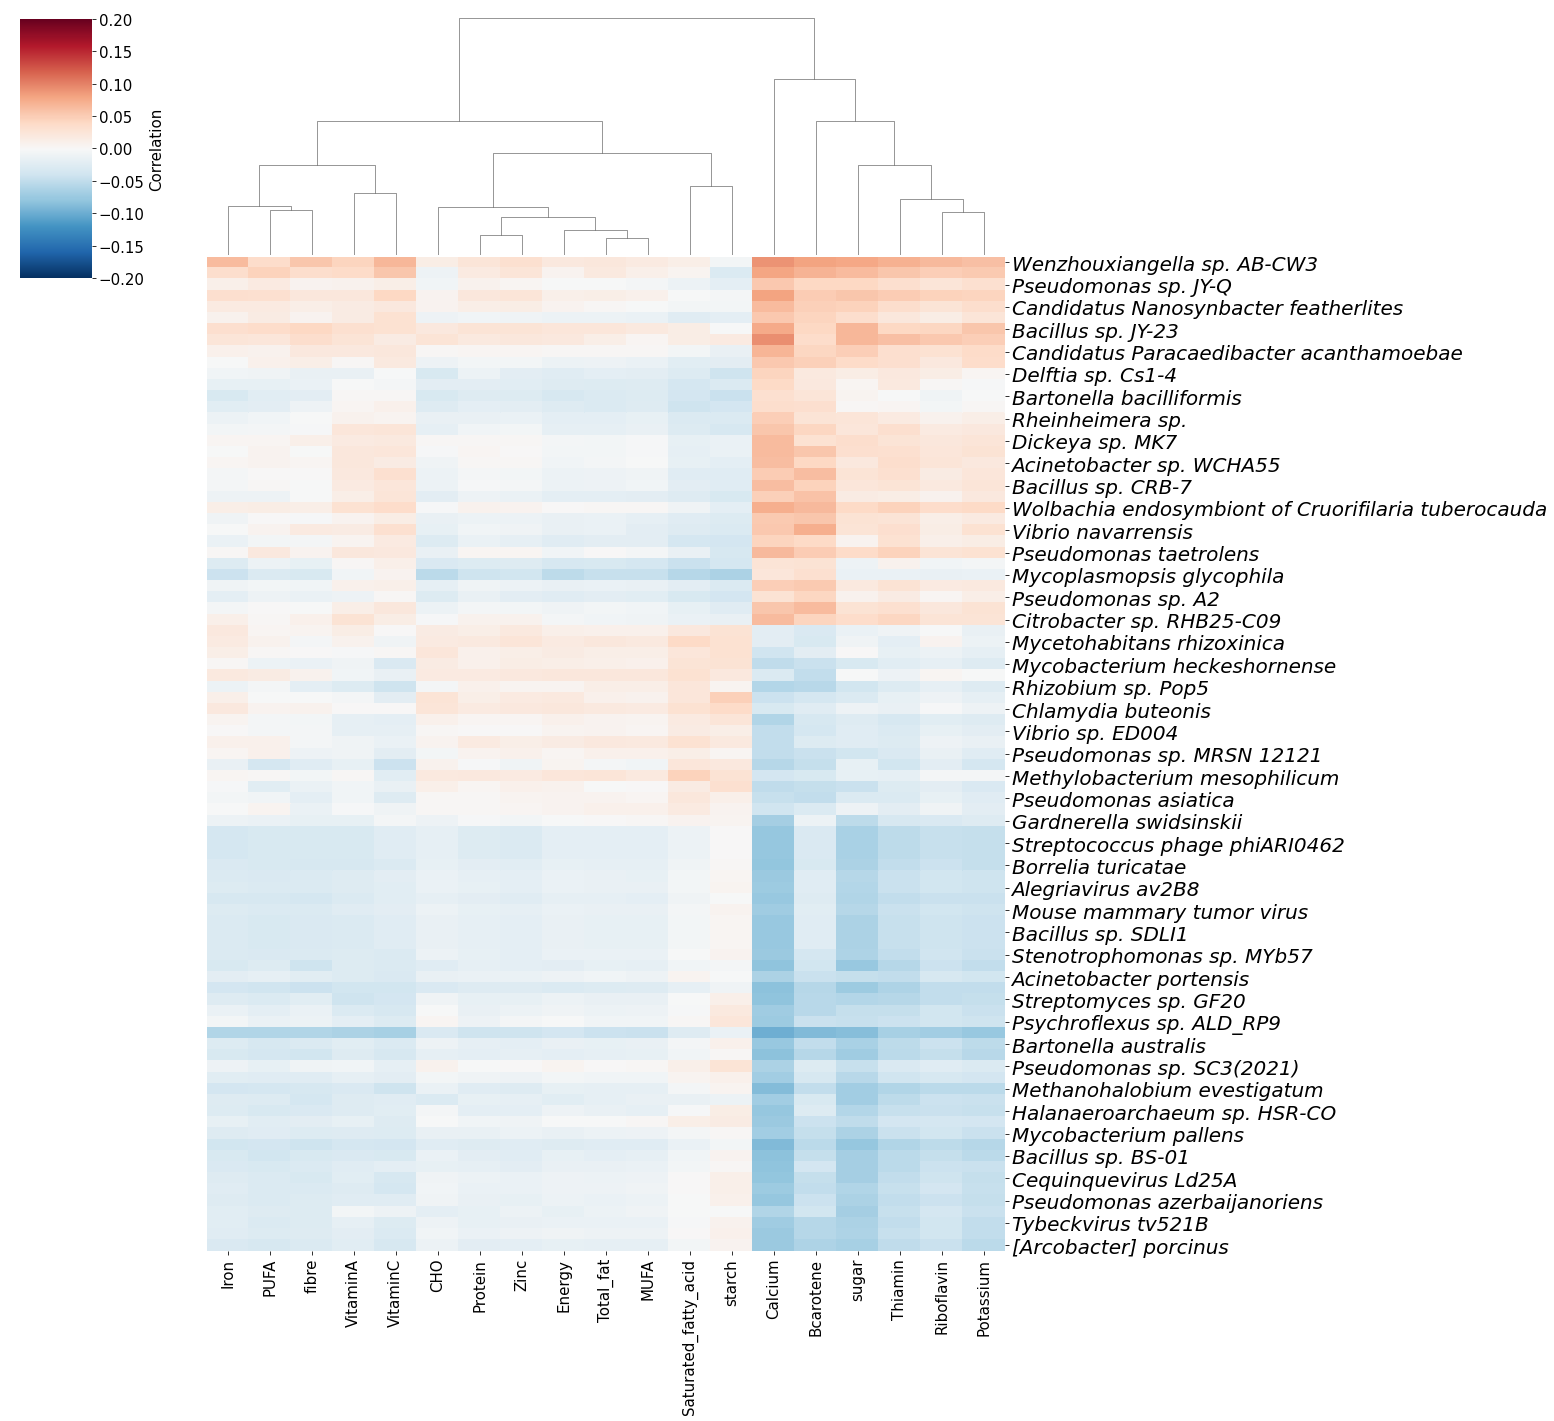

In [90]:
filtered_significance_matrix_spe = significant_matrix_spe.loc[filtered_species_spe.index, filtered_species_spe.columns]


clipped_correlations_spe = np.clip(filtered_species_spe, -0.2, 0.2)

# Setup figure settings beforehand
plt.rc('font', size=15)  # Adjusting global font size
plt.rc('axes', labelsize=15, titlesize=15)  # Adjusting label and title sizes

# Create clustermap with rows in fixed order
ax = sns.clustermap(
    clipped_correlations_spe,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={'label': 'Correlation'},
    vmin=-0.2,
    vmax=0.2,
    row_cluster=False,  # Disable row clustering
    col_cluster=True,   # Enable column clustering if desired
    figsize=(20, 20)    # Adjust size directly here if needed
)

# Since row clustering is disabled, row order is unchanged, retrieve column order
col_order = ax.dendrogram_col.reordered_ind

# Highlight significant cells (adjusted for column clustering only)
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_spe):
    if significant:
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, i + 0.5, '*', ha='center', va='center', color='black', size=10)

# Adjust y-tick labels
y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic', 'fontsize': 20})

#plt.savefig('figure/nutrition_all_spe_heatmap.png', format='png', dpi=300, bbox_inches='tight')
plt.show()